In [33]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv("../outputs/clean_tiktok_data.csv")

df.head()

,date,total_views,video,likes,comments,fave,type,tiktok_stat,category,engagement_rate,...,comment_rate,favorite_rate,month,day_of_week,week,is_weekend,engagement_rate_pct,like_rate_pct,comment_rate_pct,favorite_rate_pct
0,2026-01-01,306.0,2025 recap,10.0,3.0,0.0,vlog style,trend audio,uncategorized,0.042484,...,0.009804,0.000000,January,Thursday,1,False,4.248366,3.267974,0.980392,0.000000
1,2026-01-01,532.0,Heathrow at 8am,37.0,0.0,0.0,spam style,trend audio,travel,0.069549,...,0.000000,0.000000,January,Thursday,1,False,6.954887,6.954887,0.000000,0.000000
2,2026-01-02,552.0,Jelly cat hunting,46.0,2.0,1.0,vlog style,trend audio,knick knacks,0.088768,...,0.003623,0.001812,January,Friday,1,False,8.876812,8.333333,0.362319,0.181159
3,2026-01-02,329.0,help...(Jelly cat),18.0,1.0,1.0,tiktok style,trend audio,knick knacks,0.060790,...,0.003040,0.003040,January,Friday,1,False,6.079027,5.471125,0.303951,0.303951
4,2026-01-03,408.0,walking in suburbs,24.0,4.0,0.0,tiktok style,trend audio,uncategorized,0.068627,...,0.009804,0.000000,January,Saturday,1,True,6.862745,5.882353,0.980392,0.000000


In [35]:
df["text_features"] = (
    df["video"].fillna("") + " " +
    df["category"].fillna("") + " " +
    df["type"].fillna("") + " " +
    df["tiktok_stat"].fillna("")
)

df["text_features"].head()

0     2025 recap uncategorized vlog style trend audio 
1       Heathrow at 8am travel spam style trend audio 
2    Jelly cat hunting  knick knacks vlog style  tr...
3    help...(Jelly cat) knick knacks tiktok style t...
4    walking in suburbs  uncategorized tiktok style...
Name: text_features, dtype: str

TF-IDF Vectorization

In [36]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=100
)

X = vectorizer.fit_transform(df["text_features"])

X.shape

(260, 100)

In [37]:
feature_names = vectorizer.get_feature_names_out()

feature_names[:20]

array(['abt', 'art', 'ate', 'audio', 'bm', 'booktok', 'bree',
       'bridgerton', 'bridgeton', 'buzzball', 'car', 'cat', 'catastrophe',
       'cats', 'chicago', 'conformity', 'dallas', 'day', 'family', 'food'],
      dtype=object)

KMEANS Clustering

In [39]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df["cluster"] = kmeans.fit_predict(X)

df[["video", "cluster"]].head()

,video,cluster
0,2025 recap,4
1,Heathrow at 8am,4
2,Jelly cat hunting,4
3,help...(Jelly cat),3
4,walking in suburbs,3


In [40]:
df["cluster"].value_counts()

cluster
3    85
4    76
1    66
2    29
0     4
Name: count, dtype: int64

In [41]:
for cluster_num in range(5):
    print(f"\nCLUSTER {cluster_num}")
    print(
        df[df["cluster"] == cluster_num]["video"]
        .head(10)
        .tolist()
    )


CLUSTER 0
['self care end of kal ho na ho', 'kal ho na ho fmk', 'inaara young ho', 'kal ho na ho fountain ']

CLUSTER 1
['prince nick and jess', 'conformity gate x got s8 ', 'pitch perfect riff off', 'flashlight PP2', 'tell me lies s3 thoughts ', 'sinners oscar nom ', 'F1 oscars', 'Nosferatu v frank', 'would u rather bella v lucy ', 'soty x heated rivalry']

CLUSTER 2
['Doremi baking behind the scenes', 'this and a joke that only makes sense on this trip ', 'friends drinking before beating deadhorse', 'sardines in uber', 'sd vlog ', 'iceland wind', 'exchanging small gifts', 'rabias surprise ', 'hot ones themed bday', 'hot ones challenge crash out']

CLUSTER 3
['help...(Jelly cat)', 'walking in suburbs ', 'editing family like a reality tv mid season finale ', 'srk/kajol london statue', 'avatar river adventure', 'London transportation ', 'pub transport/what my mom hears ', 'jelly cat/heated rivalry ', 'f u and those kids', 'this and no one yapping...']

CLUSTER 4
['2025 recap', 'Heathro

In [42]:
cluster_performance = (
    df.groupby("cluster")["engagement_rate_pct"]
    .mean()
    .sort_values(ascending=False)
)

cluster_performance

cluster
2    8.937255
1    7.368463
0    7.042418
4    6.608416
3    5.940252
Name: engagement_rate_pct, dtype: float64

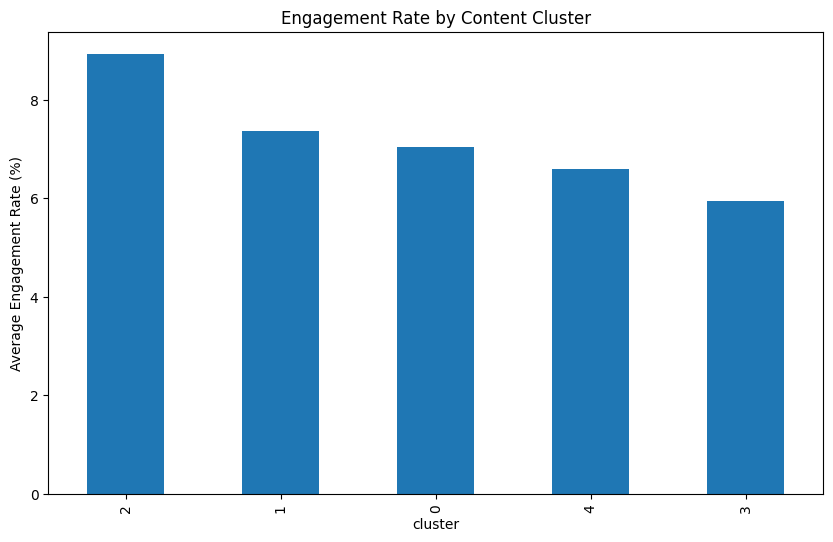

In [43]:
plt.figure(figsize=(10,6))

cluster_performance.plot(kind="bar")

plt.ylabel("Average Engagement Rate (%)")
plt.title("Engagement Rate by Content Cluster")

plt.show()

In [44]:
for cluster_num in sorted(df["cluster"].unique()):
    print(f"\n====================")
    print(f"CLUSTER {cluster_num}")
    print("====================")
    
    sample_posts = df[df["cluster"] == cluster_num][
        ["video", "category", "type", "tiktok_stat", "total_views", "engagement_rate_pct"]
    ].head(10)
    
    print(sample_posts)


CLUSTER 0
                             video   category        type     tiktok_stat  \
97   self care end of kal ho na ho  TV/movies  spam style    tiktok trend   
122               kal ho na ho fmk  TV/movies  spam style  regular audio    
129                inaara young ho    friends  spam style    tiktok trend   
241         kal ho na ho fountain      travel  spam style    trend audio    

     total_views  engagement_rate_pct  
97         366.0             3.551913  
122        383.0             5.483029  
129        868.0             9.792627  
241        760.0             9.342105  

CLUSTER 1
                           video   category        type     tiktok_stat  \
12          prince nick and jess  TV/movies  spam style    trend audio    
20     conformity gate x got s8   TV/movies  spam style    trend audio    
25        pitch perfect riff off  TV/movies  spam style  regular audio    
27                flashlight PP2  TV/movies     yapping       no audio    
42     tell me li

In [45]:
cluster_summary = (
    df.groupby("cluster")
    .agg(
        post_count=("video", "count"),
        avg_views=("total_views", "mean"),
        avg_engagement_rate_pct=("engagement_rate_pct", "mean"),
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        avg_favorites=("fave", "mean")
    )
    .reset_index()
    .sort_values(by="avg_engagement_rate_pct", ascending=False)
)

cluster_summary

,cluster,post_count,avg_views,avg_engagement_rate_pct,avg_likes,avg_comments,avg_favorites
2,2,29,2656.896552,8.937255,74.551724,2.931034,1.448276
1,1,66,24499.545455,7.368463,4065.196970,15.060606,53.242424
0,0,4,594.250000,7.042418,44.750000,2.000000,0.750000
4,4,76,6783.539474,6.608416,634.328947,5.750000,19.184211
3,3,85,1097.447059,5.940252,67.929412,2.176471,1.894118


In [46]:
df.to_csv("../outputs/clustered_tiktok_data.csv", index=False)

In [47]:
cluster_labels = {
    0: "Travel / Vlog Content",
    1: "Food / Lifestyle Content",
    2: "Friend / Social Content",
    3: "BookTok / Niche Content",
    4: "Trend Audio / Misc Content"
}

df["cluster_label"] = df["cluster"].map(cluster_labels)

df[["video", "cluster", "cluster_label"]].head()

,video,cluster,cluster_label
0,2025 recap,4,Trend Audio / Misc Content
1,Heathrow at 8am,4,Trend Audio / Misc Content
2,Jelly cat hunting,4,Trend Audio / Misc Content
3,help...(Jelly cat),3,BookTok / Niche Content
4,walking in suburbs,3,BookTok / Niche Content


In [48]:
df["cluster_label"].value_counts()

cluster_label
BookTok / Niche Content       85
Trend Audio / Misc Content    76
Food / Lifestyle Content      66
Friend / Social Content       29
Travel / Vlog Content          4
Name: count, dtype: int64

In [49]:
cluster_summary = (
    df.groupby(["cluster", "cluster_label"])
    .agg(
        post_count=("video", "count"),
        avg_views=("total_views", "mean"),
        avg_engagement_rate_pct=("engagement_rate_pct", "mean"),
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        avg_favorites=("fave", "mean")
    )
    .reset_index()
    .sort_values(by="avg_engagement_rate_pct", ascending=False)
)

cluster_summary

,cluster,cluster_label,post_count,avg_views,avg_engagement_rate_pct,avg_likes,avg_comments,avg_favorites
2,2,Friend / Social Content,29,2656.896552,8.937255,74.551724,2.931034,1.448276
1,1,Food / Lifestyle Content,66,24499.545455,7.368463,4065.196970,15.060606,53.242424
0,0,Travel / Vlog Content,4,594.250000,7.042418,44.750000,2.000000,0.750000
4,4,Trend Audio / Misc Content,76,6783.539474,6.608416,634.328947,5.750000,19.184211
3,3,BookTok / Niche Content,85,1097.447059,5.940252,67.929412,2.176471,1.894118


In [50]:
df.to_csv("../outputs/clustered_tiktok_data.csv", index=False)

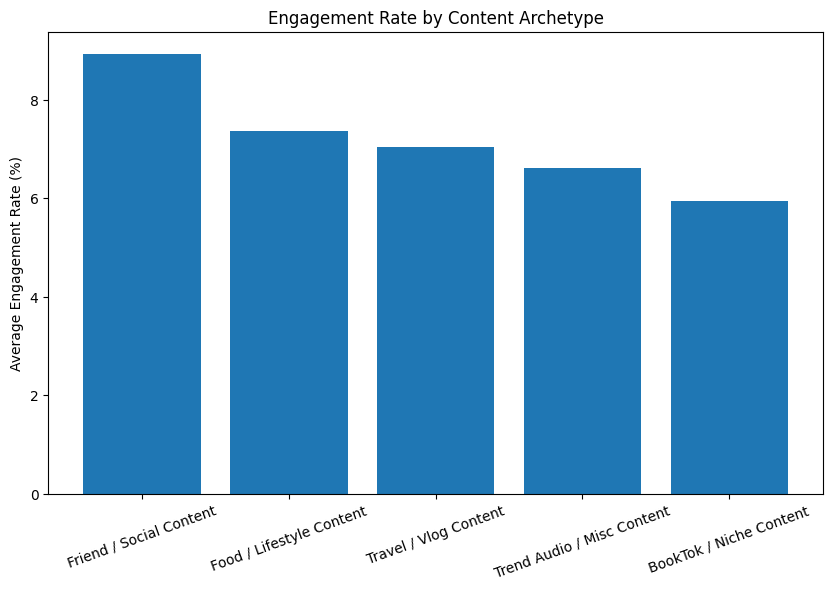

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

cluster_summary = cluster_summary.sort_values(
    by="avg_engagement_rate_pct",
    ascending=False
)

plt.bar(
    cluster_summary["cluster_label"],
    cluster_summary["avg_engagement_rate_pct"]
)

plt.xticks(rotation=20)

plt.ylabel("Average Engagement Rate (%)")
plt.title("Engagement Rate by Content Archetype")

plt.show()

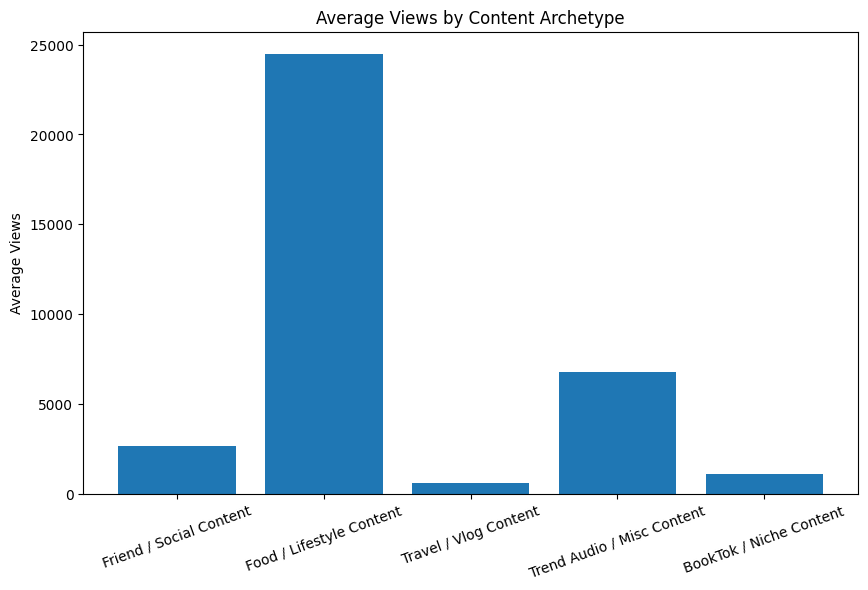

In [52]:
plt.figure(figsize=(10,6))

plt.bar(
    cluster_summary["cluster_label"],
    cluster_summary["avg_views"]
)

plt.xticks(rotation=20)

plt.ylabel("Average Views")
plt.title("Average Views by Content Archetype")

plt.show()

In [53]:
for label in df["cluster_label"].unique():
    
    print("\n====================")
    print(label)
    print("====================")
    
    print(
        df[df["cluster_label"] == label]["category"]
        .value_counts()
        .head(5)
    )


Trend Audio / Misc Content
category
uncategorized    35
travel           18
Museum           10
knick knacks      8
family            4
Name: count, dtype: int64

BookTok / Niche Content
category
food             47
travel           10
uncategorized     9
Museum            4
TV/movies         4
Name: count, dtype: int64

Food / Lifestyle Content
category
TV/movies    66
Name: count, dtype: int64

Friend / Social Content
category
friends    29
Name: count, dtype: int64

Travel / Vlog Content
category
TV/movies    2
friends      1
travel       1
Name: count, dtype: int64


Principle Componenet Analysis

In [54]:
from sklearn.decomposition import PCA

In [55]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X.toarray())

X_pca.shape

(260, 2)

In [56]:
pca_df = pd.DataFrame()

pca_df["PCA1"] = X_pca[:, 0]
pca_df["PCA2"] = X_pca[:, 1]

pca_df["cluster_label"] = df["cluster_label"]

pca_df.head()

,PCA1,PCA2,cluster_label
0,-0.117736,-0.319032,Trend Audio / Misc Content
1,-0.163230,0.105494,Trend Audio / Misc Content
2,-0.144665,-0.145553,Trend Audio / Misc Content
3,-0.185271,0.031173,BookTok / Niche Content
4,-0.245188,0.004974,BookTok / Niche Content


In [57]:
import plotly.express as px

fig = px.scatter(
    pca_df,
    x="PCA1",
    y="PCA2",
    color="cluster_label",
    title="TikTok Content Archetype Clusters"
)

fig.show()

In [58]:
terms = vectorizer.get_feature_names_out()

for i in range(5):
    print(f"\nCLUSTER {i}")
    
    center_terms = kmeans.cluster_centers_[i]
    top_terms = center_terms.argsort()[-10:][::-1]
    
    print([terms[idx] for idx in top_terms])


CLUSTER 0
['ho', 'kal', 'na', 'spam', 'inaara', 'tiktok', 'style', 'trend', 'friends', 'movies']

CLUSTER 1
['movies', 'tv', 'spam', 'audio', 'yapping', 'regular', 'trend', 'style', 'bridgerton', 'tell']

CLUSTER 2
['friends', 'vlog', 'style', 'audio', 'trend', 'spam', 'regular', 'dallas', 'game', 'tiktok']

CLUSTER 3
['tiktok', 'food', 'trend', 'style', 'audio', 'vlog', 'spam', 'travel', 'uncategorized', 'regular']

CLUSTER 4
['uncategorized', 'audio', 'vlog', 'style', 'regular', 'travel', 'trend', 'yapping', 'spam', 'museum']
